In [1]:
import pytweezer.phasemask as pm
import pytweezer.communication as com
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from rotpy.system import SpinSystem
from rotpy.camera import CameraList
from time import sleep

PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1037,
                 blaze_dx_dy_um=(110.0, 0.0))

SLM = com.SLMClient()

system = SpinSystem()
cameras = CameraList.create_from_system(system, update_cams=True, update_interfaces=True)
camera = cameras.create_camera_by_index(0)
print(f"Connected to camera: {camera.get_unique_id()}")

def GetBlackflyImage(num_average=10):
    camera.init_cam()
    camera.begin_acquisition()
    images = []
    for _ in range(num_average):
        image_cam = camera.get_next_image(timeout=5)
        image = image_cam.deep_copy_image(image_cam)
        img_arr = np.asarray(image.get_image_data()).reshape(image.get_height(), image.get_width())
        images.append(img_arr)
    image_cam.release()
    camera.end_acquisition()
    camera.deinit_cam()
    camera.release()
    return np.mean(images, axis=0)

# Write a function which generates a binary grating phasemask which takes as arguments the pixel period, the primary stripe pixel value, the secondary stripe pixel value, and the angle of the grating in degrees. The function should return a 2D numpy array of uint8 values representing the phasemask.
def generate_binary_grating_phasemask(pixel_period, primary_value, secondary_value, angle_degrees, slm_res=(1024, 1024)):
    # Create a grid of pixel coordinates
    x = np.arange(slm_res[1])
    y = np.arange(slm_res[0])
    xv, yv = np.meshgrid(x, y)

    # Convert angle to radians
    angle_radians = np.deg2rad(angle_degrees)

    # Calculate the grating pattern
    grating_pattern = (xv * np.cos(angle_radians) + yv * np.sin(angle_radians)) / pixel_period

    # Create the binary grating phasemask
    phasemask = np.where((grating_pattern % 1) < 0.5, primary_value, secondary_value).astype(np.uint8)

    return phasemask

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1037.00 mm
Blazed Grating Displacement (dx, dy): (110.0, 0.0) um
Connected to camera: 2CDDA3663AB5_0A3B0314_FFFF0000_0A3B0001


In [2]:
pm_init = PM.superimpose([PM.fresnel, PM.blaze])
pm_init_uint8 = PM.transform_phase_8bit(pm_init).get()
SLM.update_mask(pm_init_uint8)

{'status': 'success', 'msg': 'Mask updated successfully.'}

---
# Upload Grating and Image Interference Pattern

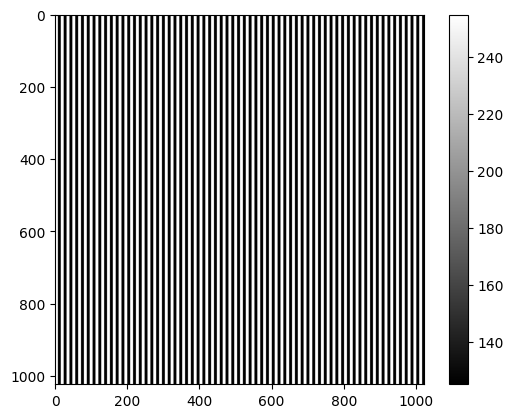

In [279]:
binary_grating = generate_binary_grating_phasemask(pixel_period=16, primary_value=255, secondary_value=125, angle_degrees=0)
plt.imshow(binary_grating, cmap='gray')
plt.colorbar()

38.4


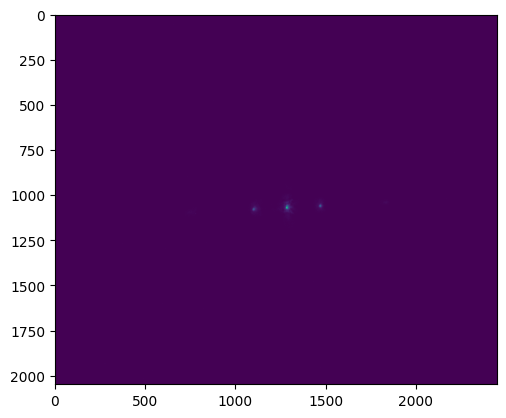

In [280]:
SLM.update_mask(binary_grating)
sleep(0.1)
out = GetBlackflyImage(num_average=10)
plt.imshow(out, cmap='viridis')
h, w = out.shape
print(out.max())

---
# Calibration Procedure

#### Find 0 and 1st Order Spots

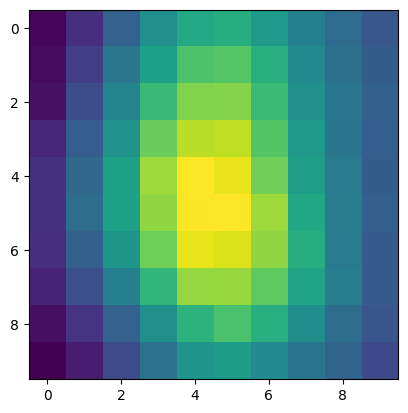

In [285]:
window = 10
x0, y0 = 60, 48
plt.imshow(out[h//2+y0-window//2:h//2+y0+window//2, w//2+x0-window//2:w//2+x0+window//2], cmap='viridis')

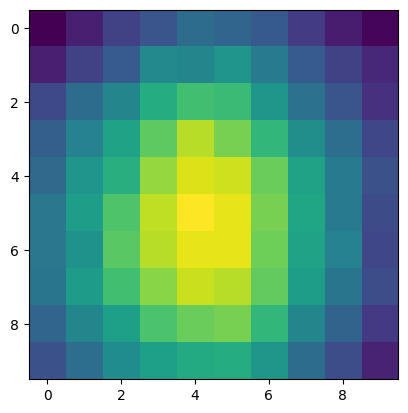

In [290]:
window = 10
x1, y1 = 62 + 184, 37
plt.imshow(out[h//2+y1-window//2:h//2+y1+window//2, w//2+x1-window//2:w//2+x1+window//2], cmap='viridis')

#### Cycle Through Binary Grating Pixel Depth and Measure Intensities

---
## Uncalibrated

In [52]:
I0_arr = []
I1_arr = []
for i in range(256):
    print(f"It {i}  |  Primary value: 255  |  Secondary value: {255 - i}")
    binary_grating = generate_binary_grating_phasemask(pixel_period=16, primary_value=255, secondary_value=255 - i, angle_degrees=0)
    SLM.update_mask(binary_grating)
    sleep(0.1)
    img = GetBlackflyImage(num_average=1)
    img0 = img[h//2+y0-window//2:h//2+y0+window//2, w//2+x0-window//2:w//2+x0+window//2]
    img1 = img[h//2+y1-window//2:h//2+y1+window//2, w//2+x1-window//2:w//2+x1+window//2]
    I0 = np.sum(img0)
    I1 = np.sum(img1)
    I0_arr.append(I0)
    I1_arr.append(I1)

It 0  |  Primary value: 255  |  Secondary value: 255
It 1  |  Primary value: 255  |  Secondary value: 254
It 2  |  Primary value: 255  |  Secondary value: 253
It 3  |  Primary value: 255  |  Secondary value: 252
It 4  |  Primary value: 255  |  Secondary value: 251
It 5  |  Primary value: 255  |  Secondary value: 250
It 6  |  Primary value: 255  |  Secondary value: 249
It 7  |  Primary value: 255  |  Secondary value: 248
It 8  |  Primary value: 255  |  Secondary value: 247
It 9  |  Primary value: 255  |  Secondary value: 246
It 10  |  Primary value: 255  |  Secondary value: 245
It 11  |  Primary value: 255  |  Secondary value: 244
It 12  |  Primary value: 255  |  Secondary value: 243
It 13  |  Primary value: 255  |  Secondary value: 242
It 14  |  Primary value: 255  |  Secondary value: 241
It 15  |  Primary value: 255  |  Secondary value: 240
It 16  |  Primary value: 255  |  Secondary value: 239
It 17  |  Primary value: 255  |  Secondary value: 238
It 18  |  Primary value: 255  |  Secon

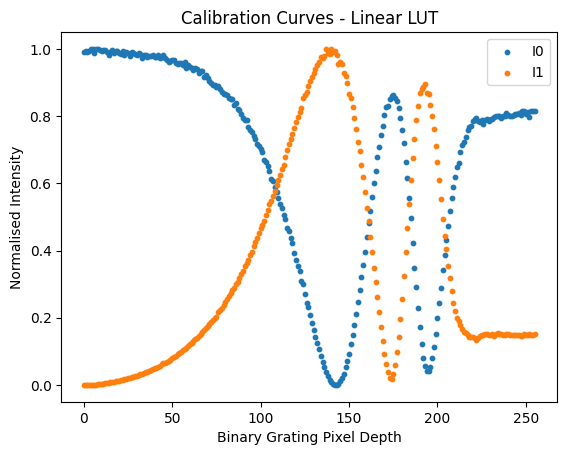

In [61]:
I0_norm = (I0_arr - np.min(I0_arr)) / (np.max(I0_arr) - np.min(I0_arr))
I1_norm = (I1_arr - np.min(I1_arr)) / (np.max(I1_arr) - np.min(I1_arr))
plt.scatter(range(256), I0_norm, label='I0', s=10)
plt.scatter(range(256), I1_norm, label='I1', s=10)
plt.xlabel('Binary Grating Pixel Depth')
plt.ylabel('Normalised Intensity')
plt.title('Calibration Curves - Linear LUT')
plt.legend()
plt.show()

In [63]:
grays = [i for i in range(256)]

# Write a csv file with two columns where the first column are the elements of the list 'grays' and the second column are the elements of the array I1_arr. Do not include a header row in the csv file.
import csv

with open('raw0.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    for gray, i1 in zip(grays, I1_norm):
        writer.writerow([gray, i1])

---
## Manufacturer Calibrated - 785 nm at 75°C

In [59]:
I0_arr = []
I1_arr = []
for i in range(256):
    print(f"It {i}  |  Primary value: 255  |  Secondary value: {255 - i}")
    binary_grating = generate_binary_grating_phasemask(pixel_period=16, primary_value=255, secondary_value=255 - i, angle_degrees=0)
    SLM.update_mask(binary_grating)
    sleep(0.1)
    img = GetBlackflyImage(num_average=10)
    img0 = img[h//2+y0-window//2:h//2+y0+window//2, w//2+x0-window//2:w//2+x0+window//2]
    img1 = img[h//2+y1-window//2:h//2+y1+window//2, w//2+x1-window//2:w//2+x1+window//2]
    I0 = np.sum(img0)
    I1 = np.sum(img1)
    I0_arr.append(I0)
    I1_arr.append(I1)

It 0  |  Primary value: 255  |  Secondary value: 255
It 1  |  Primary value: 255  |  Secondary value: 254
It 2  |  Primary value: 255  |  Secondary value: 253
It 3  |  Primary value: 255  |  Secondary value: 252
It 4  |  Primary value: 255  |  Secondary value: 251
It 5  |  Primary value: 255  |  Secondary value: 250
It 6  |  Primary value: 255  |  Secondary value: 249
It 7  |  Primary value: 255  |  Secondary value: 248
It 8  |  Primary value: 255  |  Secondary value: 247
It 9  |  Primary value: 255  |  Secondary value: 246
It 10  |  Primary value: 255  |  Secondary value: 245
It 11  |  Primary value: 255  |  Secondary value: 244
It 12  |  Primary value: 255  |  Secondary value: 243
It 13  |  Primary value: 255  |  Secondary value: 242
It 14  |  Primary value: 255  |  Secondary value: 241
It 15  |  Primary value: 255  |  Secondary value: 240
It 16  |  Primary value: 255  |  Secondary value: 239
It 17  |  Primary value: 255  |  Secondary value: 238
It 18  |  Primary value: 255  |  Secon

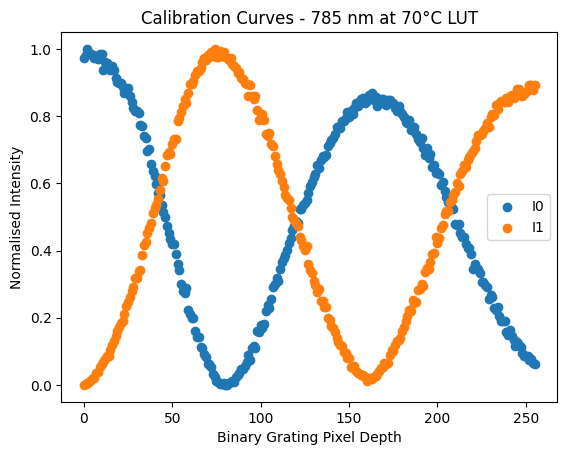

In [58]:
I0_norm = (I0_arr - np.min(I0_arr)) / (np.max(I0_arr) - np.min(I0_arr))
I1_norm = (I1_arr - np.min(I1_arr)) / (np.max(I1_arr) - np.min(I1_arr))
plt.scatter(range(256), I0_norm, label='I0')
plt.scatter(range(256), I1_norm, label='I1')
plt.xlabel('Binary Grating Pixel Depth')
plt.ylabel('Normalised Intensity')
plt.title('Calibration Curves - 785 nm at 70°C LUT')
plt.legend()
plt.show()

---
## Calibrated - 852 nm at 33°C

In [64]:
I0_arr = []
I1_arr = []
for i in range(256):
    print(f"It {i}  |  Primary value: 255  |  Secondary value: {255 - i}")
    binary_grating = generate_binary_grating_phasemask(pixel_period=16, primary_value=255, secondary_value=255 - i, angle_degrees=0)
    SLM.update_mask(binary_grating)
    sleep(0.1)
    img = GetBlackflyImage(num_average=1)
    img0 = img[h//2+y0-window//2:h//2+y0+window//2, w//2+x0-window//2:w//2+x0+window//2]
    img1 = img[h//2+y1-window//2:h//2+y1+window//2, w//2+x1-window//2:w//2+x1+window//2]
    I0 = np.sum(img0)
    I1 = np.sum(img1)
    I0_arr.append(I0)
    I1_arr.append(I1)

It 0  |  Primary value: 255  |  Secondary value: 255
It 1  |  Primary value: 255  |  Secondary value: 254
It 2  |  Primary value: 255  |  Secondary value: 253
It 3  |  Primary value: 255  |  Secondary value: 252
It 4  |  Primary value: 255  |  Secondary value: 251
It 5  |  Primary value: 255  |  Secondary value: 250
It 6  |  Primary value: 255  |  Secondary value: 249
It 7  |  Primary value: 255  |  Secondary value: 248
It 8  |  Primary value: 255  |  Secondary value: 247
It 9  |  Primary value: 255  |  Secondary value: 246
It 10  |  Primary value: 255  |  Secondary value: 245
It 11  |  Primary value: 255  |  Secondary value: 244
It 12  |  Primary value: 255  |  Secondary value: 243
It 13  |  Primary value: 255  |  Secondary value: 242
It 14  |  Primary value: 255  |  Secondary value: 241
It 15  |  Primary value: 255  |  Secondary value: 240
It 16  |  Primary value: 255  |  Secondary value: 239
It 17  |  Primary value: 255  |  Secondary value: 238
It 18  |  Primary value: 255  |  Secon

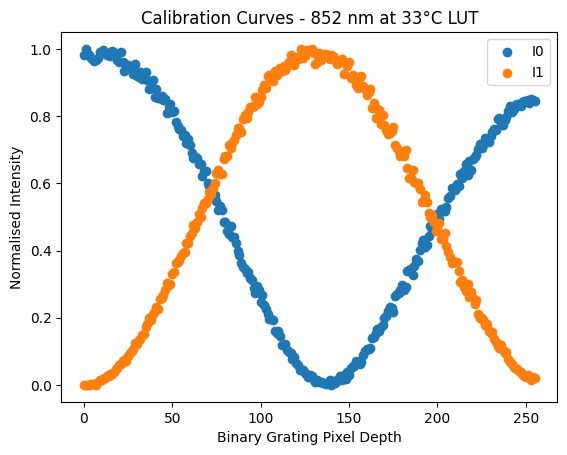

In [65]:
I0_norm = (I0_arr - np.min(I0_arr)) / (np.max(I0_arr) - np.min(I0_arr))
I1_norm = (I1_arr - np.min(I1_arr)) / (np.max(I1_arr) - np.min(I1_arr))
plt.scatter(range(256), I0_norm, label='I0')
plt.scatter(range(256), I1_norm, label='I1')
plt.xlabel('Binary Grating Pixel Depth')
plt.ylabel('Normalised Intensity')
plt.title('Calibration Curves - 852 nm at 33°C LUT')
plt.legend()
plt.show()

In [66]:
grays = [i for i in range(256)]

# Write a csv file with two columns where the first column are the elements of the list 'grays' and the second column are the elements of the array I1_arr. Do not include a header row in the csv file.
import csv

with open('raw0_calibrated.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    for gray, i1 in zip(grays, I1_norm):
        writer.writerow([gray, i1])

---
## Calibrating - 852 nm at 40°C

In [298]:
SLM.get_temperature()

{'status': 'success', 'data': 39.925250227090416}

In [292]:
I0_arr = []
I1_arr = []
for i in range(256):
    print(f"It {i}  |  Primary value: 255  |  Secondary value: {255 - i}")
    binary_grating = generate_binary_grating_phasemask(pixel_period=16, primary_value=255, secondary_value=255 - i, angle_degrees=0)
    SLM.update_mask(binary_grating)
    sleep(0.1)
    img = GetBlackflyImage(num_average=10)
    img0 = img[h//2+y0-window//2:h//2+y0+window//2, w//2+x0-window//2:w//2+x0+window//2]
    img1 = img[h//2+y1-window//2:h//2+y1+window//2, w//2+x1-window//2:w//2+x1+window//2]
    I0 = np.sum(img0)
    I1 = np.sum(img1)
    I0_arr.append(I0)
    I1_arr.append(I1)

It 0  |  Primary value: 255  |  Secondary value: 255
It 1  |  Primary value: 255  |  Secondary value: 254
It 2  |  Primary value: 255  |  Secondary value: 253
It 3  |  Primary value: 255  |  Secondary value: 252
It 4  |  Primary value: 255  |  Secondary value: 251
It 5  |  Primary value: 255  |  Secondary value: 250
It 6  |  Primary value: 255  |  Secondary value: 249
It 7  |  Primary value: 255  |  Secondary value: 248
It 8  |  Primary value: 255  |  Secondary value: 247
It 9  |  Primary value: 255  |  Secondary value: 246
It 10  |  Primary value: 255  |  Secondary value: 245
It 11  |  Primary value: 255  |  Secondary value: 244
It 12  |  Primary value: 255  |  Secondary value: 243
It 13  |  Primary value: 255  |  Secondary value: 242
It 14  |  Primary value: 255  |  Secondary value: 241
It 15  |  Primary value: 255  |  Secondary value: 240
It 16  |  Primary value: 255  |  Secondary value: 239
It 17  |  Primary value: 255  |  Secondary value: 238
It 18  |  Primary value: 255  |  Secon

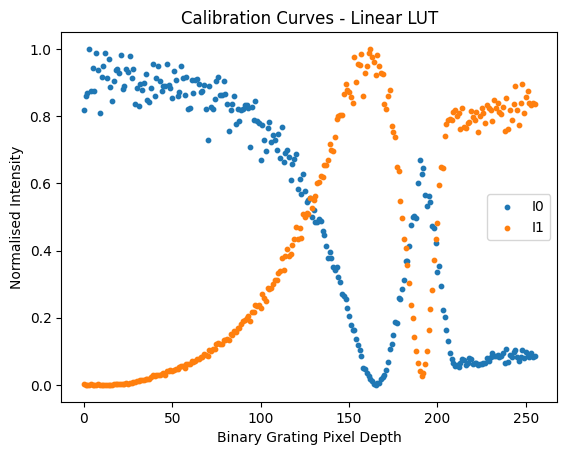

In [295]:
I0_norm = (I0_arr - np.min(I0_arr)) / (np.max(I0_arr) - np.min(I0_arr))
I1_norm = (I1_arr - np.min(I1_arr)) / (np.max(I1_arr) - np.min(I1_arr))
plt.scatter(range(256), I0_norm, label='I0', s=10)
plt.scatter(range(256), I1_norm, label='I1', s=10)
plt.xlabel('Binary Grating Pixel Depth')
plt.ylabel('Normalised Intensity')
plt.title('Calibration Curves - Linear LUT')
plt.legend()
plt.show()

In [296]:
grays = [i for i in range(256)]

# Write a csv file with two columns where the first column are the elements of the list 'grays' and the second column are the elements of the array I1_arr. Do not include a header row in the csv file.
import csv

with open('raw0.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    for gray, i1 in zip(grays, I1_norm):
        writer.writerow([gray, i1])

---